In [64]:
import torch
import numpy as np
from typing import List
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

from mars.population.transform import reshape_superoperators_list_to_direct_sum_basis, Liouvilleator
import mars

In [65]:
dephasing_factor = 1e7
lorentz = mars.constants.unit_converter(dephasing_factor / 3.14, "Hz_to_T_e")


dtype = torch.float64
torch.seed = 23

def get_sample():
    g_interaction = mars.spin_model.Interaction((2.002, 2.003, 2.004), dtype=dtype)
    zfs = mars.spin_model.DEInteraction((100e6, 20e6), dtype=dtype)
    spin_system = mars.spin_model.SpinSystem(electrons=[1.0], g_tensors=[g_interaction], electron_electron=[(0, 0, zfs)])
    sample = mars.spin_model.MultiOrientedSample(base_spin_system=spin_system, dtype=dtype, lorentz=2.02 * lorentz)
    return sample

def get_context(sample):
    spin_system_dim = sample.spin_system_dim
    rates = torch.randn((spin_system_dim, spin_system_dim), dtype=dtype) * 1.0
    dephasing = torch.ones((spin_system_dim, ), dtype=dtype) * dephasing_factor
    init_populations = torch.randn((spin_system_dim, ), dtype=dtype).abs()
    init_populations = init_populations / init_populations.sum(-1)
    
    idx = torch.arange(spin_system_dim)
    rates[..., idx, idx] = 0.0
    rates = rates.abs()
    context = mars.population.Context(basis="eigen", free_probs=rates, init_populations=init_populations, dephasing=dephasing, dtype=dtype)
    return context

In [66]:
fields = torch.linspace(0.339, 0.3525, 150, dtype=dtype)
time = torch.linspace(0.0, 10, 250, dtype=dtype)

sample = get_sample()
context = get_context(sample)

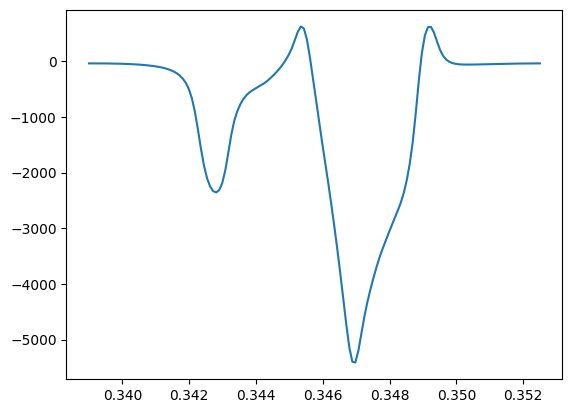

In [67]:
spec_st = mars.spectra_manager.StationarySpectra(freq=9.7*1e9, sample=sample, harmonic=0, context=context, dtype=dtype)(sample, fields)
plt.plot(fields, spec_st)

In [68]:
manager = mars.spectra_manager.BaseDirectSpectra(freq=9.7*1e9, sample=sample, harmonic=0, context=context, dtype=dtype)
spec = manager(sample, fields, time)

C:\Users\User\AppData\Local\Temp\ipykernel_4228\701919712.py:1: UserWarning: For direct spectra computations, all broadening parameters are skipped.
  manager = mars.spectra_manager.BaseDirectSpectra(freq=9.7*1e9, sample=sample, harmonic=0, context=context, dtype=dtype)


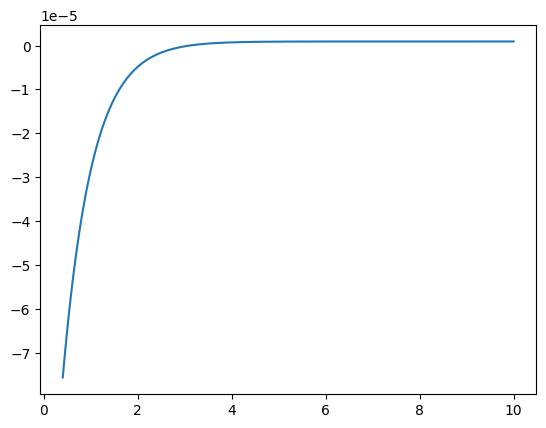

In [69]:
plt.plot(time[10:], spec[10:, 10])

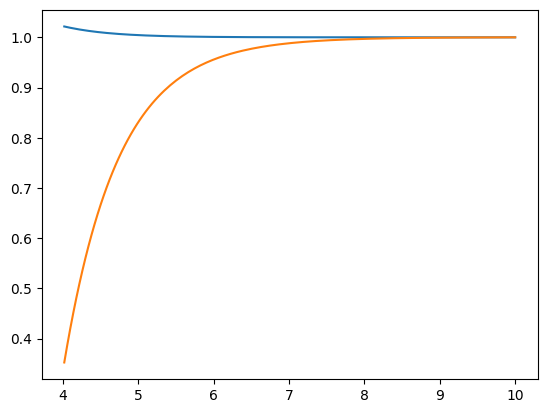

In [70]:
manager_res = mars.spectra_manager.DensityTimeSpectra(freq=9.7*1e9, sample=sample, harmonic=0, context=context, dtype=dtype)
spec_res = manager_res(sample, fields, time)
plt.plot(time[100:], spec_res[100:, 25] / spec_res[:, 25][-1])
plt.plot(time[100:], spec[100:, 25] / spec[:, 25][-1])

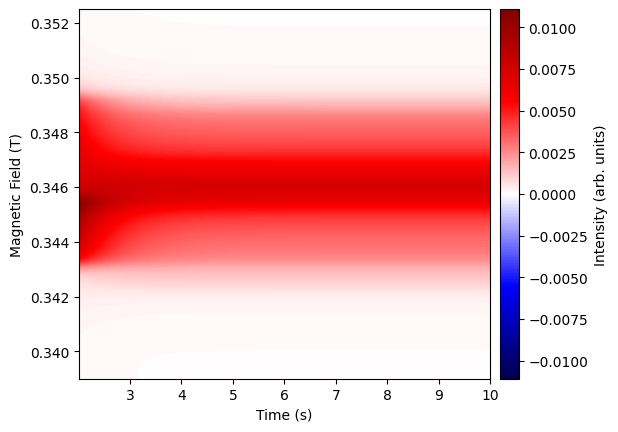

In [71]:
spec_res = spec_res/ torch.max(spec_res)
mars.visualization.plot_2d_timeresolved(fields, time[50:], spec_res[50:], )

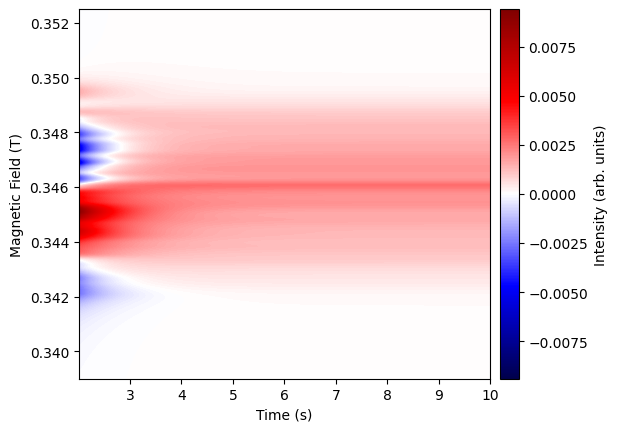

In [72]:
spec = spec / torch.max(spec)
mars.visualization.plot_2d_timeresolved(fields, time[50:], spec[50:])

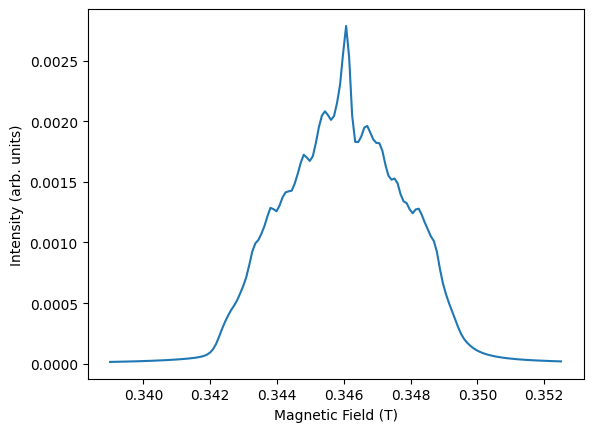

In [73]:
mars.visualization.plot_field_dependence(5, fields, time, spec)

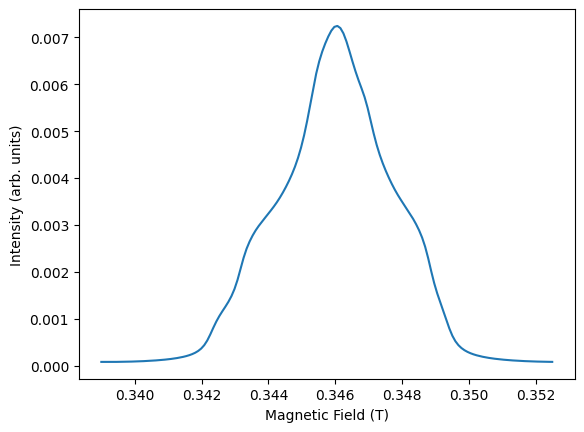

In [74]:
mars.visualization.plot_field_dependence(5, fields, time, spec_res)